In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        
        # C1: 1 input image channel, 6 output channels, 5x5 square convolution
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        
        # S2: Max pooling layer with 2x2 kernel and stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # C3: 6 input channels, 16 output channels, 5x5 square convolution
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        
        # S4: Max pooling layer with 2x2 kernel and stride 2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # C5: 16 input channels, 120 output channels, 5x5 square convolution
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        
        # F6: Fully connected layer
        self.fc1 = nn.Linear(120, 84)
        
        # Output level: Fully connected layer
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        # Substituído torch.tanh por F.relu
        # Aplicando C1 seguido de ReLU e S2 pooling
        x = self.pool1(F.relu(self.conv1(x)))
        
        # Aplicando C3 seguido de ReLU e S4 pooling
        x = self.pool2(F.relu(self.conv2(x)))
        
        # Aplicando C5 seguido de ReLU
        x = F.relu(self.conv3(x))
        
        # Flatten (estilo x.view como o do professor)
        x = x.view(x.size(0), -1)
        
        # Aplicando F6 seguido de ReLU
        x = F.relu(self.fc1(x))
        
        # Final output layer (geralmente não usa ativação antes da perda)
        x = self.fc2(x)
        
        return x

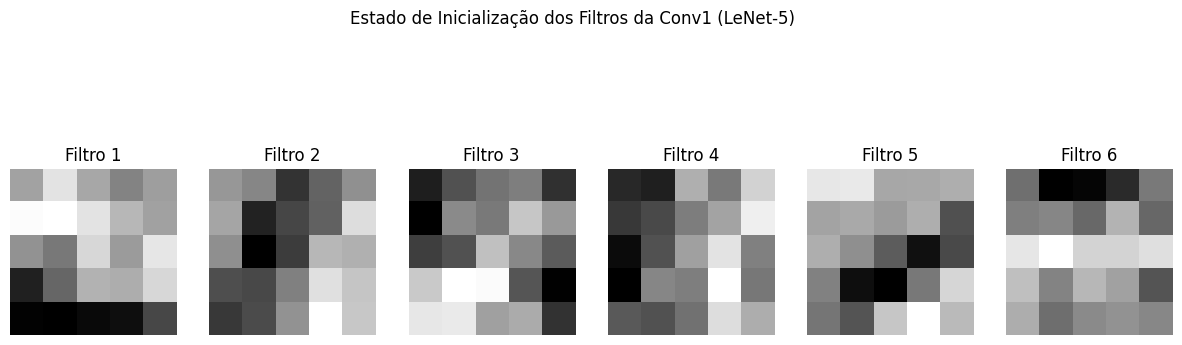

In [26]:
import matplotlib.pyplot as plt

# 1. Instancia o modelo LeNet5
# model = LeNet5(num_classes=10)

# 2. Extrai os filtros da primeira camada convolucional (conv1)
# O .cpu() garante que os dados venham para o processador antes de virar imagem
filters = model.conv1.weight.detach().cpu()

# 3. Configura a plotagem dos filtros
fig, axes = plt.subplots(1, 6, figsize=(15, 5))

for i, ax in enumerate(axes):
    # Mostra o i-ésimo filtro em escala de cinza
    # O índice [i, 0] pega o filtro 'i' e o primeiro canal de cor (MNIST é PB)
    ax.imshow(filters[i, 0], cmap='gray')
    ax.set_title(f'Filtro {i+1}')
    ax.axis('off')

# 4. Adiciona um título principal e exibe
plt.suptitle('Estado de Inicialização dos Filtros da Conv1 (LeNet-5)')
plt.show()

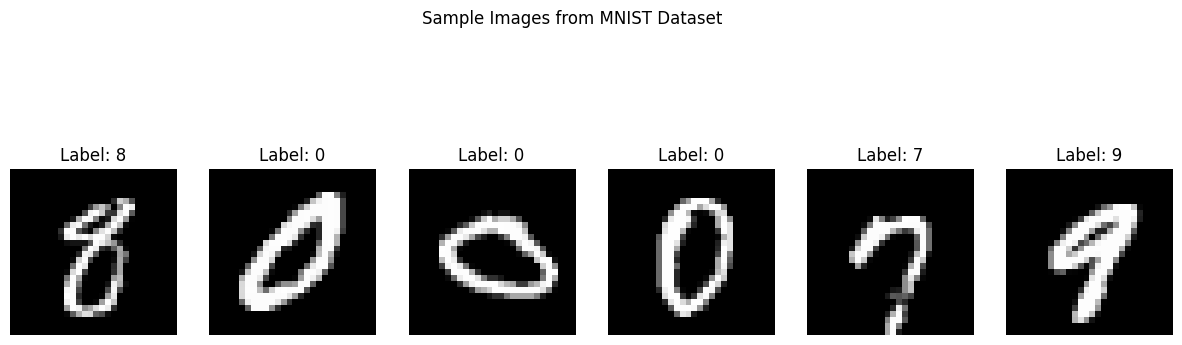

In [27]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Define transform to convert images to tensors
transform = transforms.Compose([transforms.ToTensor()])

# 2. Download and load training data
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 3. Get some random images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# 4. Plot images
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')

plt.suptitle('Sample Images from MNIST Dataset')
plt.show()

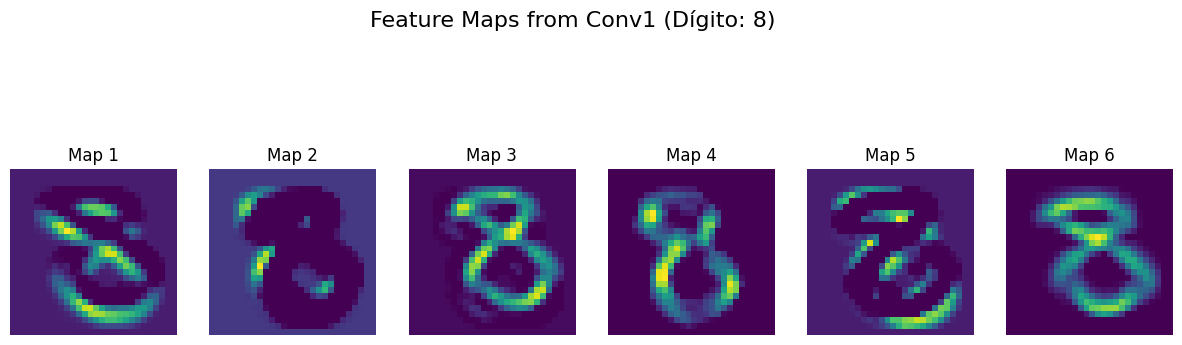

In [28]:
import torch.nn.functional as F

# 1. Pega uma única imagem de exemplo (vamos pegar a primeira do batch)
sample_image = images[9].unsqueeze(0) # Adiciona uma dimensão para o batch (1, 1, 28, 28)
sample_label = labels[9].item()

# 2. Passa a imagem APENAS pela primeira camada (conv1) do seu modelo
# O .to(device) garante que a imagem esteja no mesmo lugar que o modelo (CPU ou GPU)
device = next(model.parameters()).device
with torch.no_grad():
    feature_maps = F.relu(model.conv1(sample_image.to(device)))

# 3. Move de volta para a CPU para plotar
feature_maps = feature_maps.cpu()

# 4. Configura a plotagem (6 filtros da LeNet-5)
fig, axes = plt.subplots(1, 6, figsize=(15, 5))

for i in range(6):
    # cmap='viridis' dá o efeito roxo e amarelo (o 'gray' seria só preto e branco)
    axes[i].imshow(feature_maps[0, i], cmap='viridis')
    axes[i].set_title(f'Map {i+1}')
    axes[i].axis('off')

plt.suptitle(f'Feature Maps from Conv1 (Dígito: {sample_label})', fontsize=16)
plt.show()

In [29]:
import torch.optim as optim

# 1. Configuração do dispositivo de processamento (GPU se disponível)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

# 2. Instancia o modelo e envia para o dispositivo
model = LeNet5(num_classes=10).to(device)

# 3. Definição da função de perda e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Loop de Treinamento
epochs = 5
print("\n--- Iniciando Treinamento ---")
for epoch in range(epochs):
    model.train() # Coloca o modelo em modo de treinamento
    running_loss = 0.0
    
    for i, (inputs, labels) in enumerate(train_loader):
        # Mover dados para a GPU (ou CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zerar gradientes acumulados no backward pass anterior
        optimizer.zero_grad()
        
        # Forward pass: calcular predições do modelo
        outputs = model(inputs)
        
        # Calcular a perda
        loss = criterion(outputs, labels)
        
        # Backward pass: calcular gradientes
        loss.backward()
        
        # Atualizar pesos
        optimizer.step()
        
        running_loss += loss.item()
        if (i + 1) % 200 == 0:    # Mostrar progresso a cada 2000 batches
            print(f'Época [{epoch + 1}/{epochs}], Passo [{i + 1}/{len(train_loader)}], Loss: {running_loss / 2000:.4f}')
            running_loss = 0.0

print("Treinamento finalizado!")

Usando dispositivo: cpu

--- Iniciando Treinamento ---
Época [1/5], Passo [200/938], Loss: 0.0759
Época [1/5], Passo [400/938], Loss: 0.0236
Época [1/5], Passo [600/938], Loss: 0.0158
Época [1/5], Passo [800/938], Loss: 0.0112
Época [2/5], Passo [200/938], Loss: 0.0089
Época [2/5], Passo [400/938], Loss: 0.0087
Época [2/5], Passo [600/938], Loss: 0.0078
Época [2/5], Passo [800/938], Loss: 0.0067
Época [3/5], Passo [200/938], Loss: 0.0057
Época [3/5], Passo [400/938], Loss: 0.0054
Época [3/5], Passo [600/938], Loss: 0.0059
Época [3/5], Passo [800/938], Loss: 0.0051
Época [4/5], Passo [200/938], Loss: 0.0045
Época [4/5], Passo [400/938], Loss: 0.0045
Época [4/5], Passo [600/938], Loss: 0.0041
Época [4/5], Passo [800/938], Loss: 0.0048
Época [5/5], Passo [200/938], Loss: 0.0039
Época [5/5], Passo [400/938], Loss: 0.0041
Época [5/5], Passo [600/938], Loss: 0.0035
Época [5/5], Passo [800/938], Loss: 0.0035
Treinamento finalizado!


In [30]:
# Load test dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Set model to evaluation mode
model.eval()

correct = 0
total = 0

# No gradient calculation needed during evaluation
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the network on the 10,000 test images: {accuracy:.2f}%')

Accuracy of the network on the 10,000 test images: 98.72%
